In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('./heart_clean.csv')

In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

In [6]:
df = df.dropna()

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [9]:
df = pd.get_dummies(df, columns=['cp'], drop_first=True)


In [10]:
df = pd.get_dummies(df, columns=['restecg'], drop_first=True)

In [11]:
df = pd.get_dummies(df, columns=['thal'], drop_first=True)

In [12]:
df = pd.get_dummies(df, columns=['slope'], drop_first=True)

In [13]:
X = df.drop('target', axis=1)
y = df['target']
y = (y > 0).astype(int)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
"""from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['cp', 'restecg', 'thal', 'slope']  # whichever you're treating as nominal

encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])   # transform only, no fit

# get readable column names back
encoded_cols = encoder.get_feature_names_out(categorical_cols)"""

"from sklearn.preprocessing import OneHotEncoder\n\ncategorical_cols = ['cp', 'restecg', 'thal', 'slope']  # whichever you're treating as nominal\n\nencoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)\n\nX_train_cat = encoder.fit_transform(X_train[categorical_cols])\nX_test_cat = encoder.transform(X_test[categorical_cols])   # transform only, no fit\n\n# get readable column names back\nencoded_cols = encoder.get_feature_names_out(categorical_cols)"

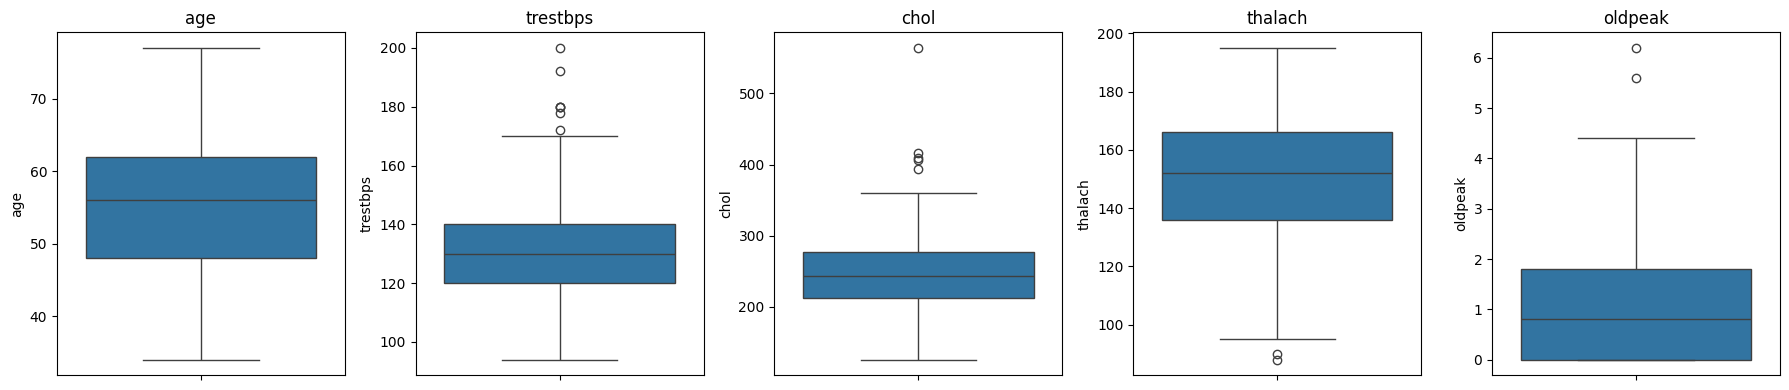

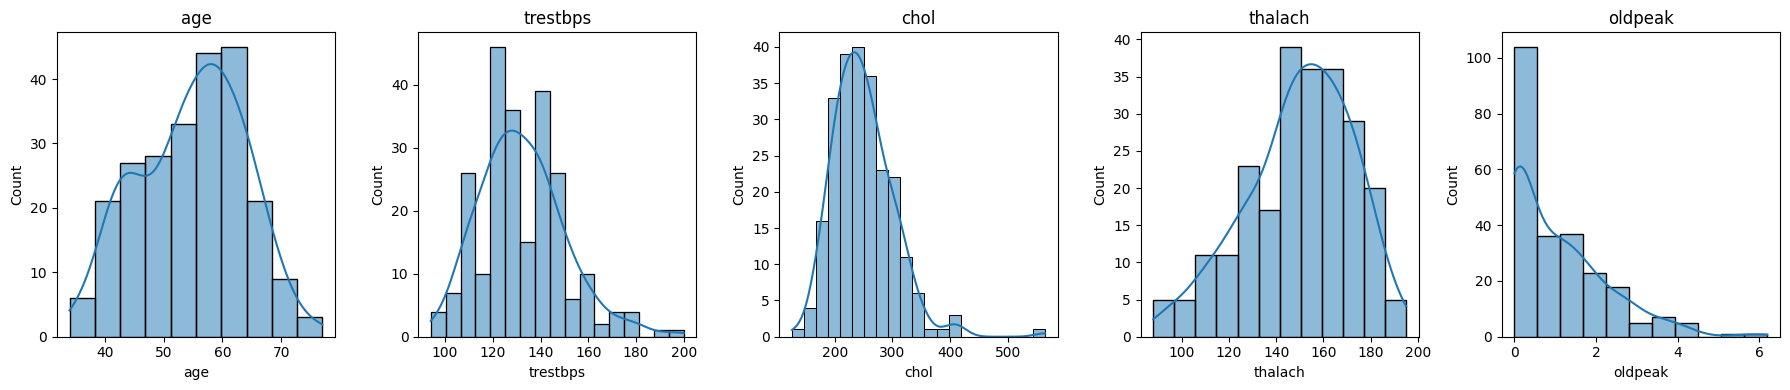

age        -0.159085
trestbps    0.668621
chol        1.318058
thalach    -0.490182
oldpeak     1.305929
dtype: float64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Boxplots for outliers
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 4))
for ax, col in zip(axes, continuous_cols):
    sns.boxplot(y=X_train[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Histograms for skew
fig, axes = plt.subplots(1, len(continuous_cols), figsize=(18, 4))
for ax, col in zip(axes, continuous_cols):
    sns.histplot(X_train[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Numeric skew values — a clean way to justify your choice without eyeballing only
X_train[continuous_cols].skew()

In [16]:
"""from sklearn.preprocessing import RobustScaler

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = RobustScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])"""

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), ['age']),
    ('robust', RobustScaler(), ['trestbps', 'chol', 'thalach', 'oldpeak']),
], remainder='passthrough')

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [17]:
"""from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder

categorical_cols = ['cp', 'restecg', 'thal', 'slope']

preprocessor = ColumnTransformer(transformers=[
    ('standard', StandardScaler(), ['age']),
    ('robust', RobustScaler(), ['trestbps', 'chol', 'thalach', 'oldpeak']),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
], remainder='passthrough')  # passes sex, fbs, exang through unchanged — already 0/1

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)"""

"from sklearn.compose import ColumnTransformer\nfrom sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder\n\ncategorical_cols = ['cp', 'restecg', 'thal', 'slope']\n\npreprocessor = ColumnTransformer(transformers=[\n    ('standard', StandardScaler(), ['age']),\n    ('robust', RobustScaler(), ['trestbps', 'chol', 'thalach', 'oldpeak']),\n    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),\n], remainder='passthrough')  # passes sex, fbs, exang through unchanged — already 0/1\n\nX_train_processed = preprocessor.fit_transform(X_train)\nX_test_processed = preprocessor.transform(X_test)"

In [18]:
y_train.value_counts(normalize=True)

target
0    0.540084
1    0.459916
Name: proportion, dtype: float64

In [19]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

log_reg = LogisticRegression(max_iter=1000, random_state=42)

scores = cross_validate(
    log_reg, X_train_scaled, y_train,
    cv=cv,  
    scoring=['roc_auc', 'accuracy', 'f1', 'recall', 'precision'],
    return_train_score=True
)

print("Train ROC-AUC:", scores['train_roc_auc'].mean())
print("Val ROC-AUC:", scores['test_roc_auc'].mean())
print("Val F1:", scores['test_f1'].mean())
print("Val Recall:", scores['test_recall'].mean())

Train ROC-AUC: 0.9300247398063425
Val ROC-AUC: 0.8916370296370296
Val F1: 0.7861498708010337
Val Recall: 0.751082251082251


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf_scores = cross_validate(
    rf, X_train_scaled, y_train,
    cv=cv,
    scoring=['roc_auc', 'accuracy', 'f1', 'recall', 'precision'],
    return_train_score=True
)

print("Train ROC-AUC:", rf_scores['train_roc_auc'].mean())
print("Val ROC-AUC:", rf_scores['test_roc_auc'].mean())
print("Val F1:", rf_scores['test_f1'].mean())
print("Val Recall:", rf_scores['test_recall'].mean())

Train ROC-AUC: 1.0
Val ROC-AUC: 0.8786027306027305
Val F1: 0.7513648536337613
Val Recall: 0.705194805194805


In [28]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

rf_tuned_scores = cross_validate(
    rf_tuned, X_train_scaled, y_train,
    cv=cv,
    scoring=['roc_auc', 'accuracy', 'f1', 'recall', 'precision'],
    return_train_score=True
)

print("Train ROC-AUC:", rf_tuned_scores['train_roc_auc'].mean())
print("Val ROC-AUC:", rf_tuned_scores['test_roc_auc'].mean())
print("Val F1:", rf_tuned_scores['test_f1'].mean())
print("Val Recall:", rf_tuned_scores['test_recall'].mean())

Train ROC-AUC: 0.9728016990241531
Val ROC-AUC: 0.9013446553446552
Val F1: 0.7836045091859045
Val Recall: 0.751082251082251


In [30]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 10),
    'min_samples_leaf': randint(2, 10),
    'max_features': ['sqrt', 'log2'],
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=25,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print("Best params:", random_search.best_params_)
print("Best CV ROC-AUC:", random_search.best_score_)

Best params: {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 6, 'n_estimators': 101}
Best CV ROC-AUC: 0.9038901098901098


In [36]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=50,
    max_depth=5,
    learning_rate=0.02,
    random_state=42,
    eval_metric='logloss'
)

xgb_scores = cross_validate(
    xgb, X_train_scaled, y_train,
    cv=cv,
    scoring=['roc_auc', 'f1', 'recall'],
    return_train_score=True
)

print("Train ROC-AUC:", xgb_scores['train_roc_auc'].mean())
print("Val ROC-AUC:", xgb_scores['test_roc_auc'].mean())

Train ROC-AUC: 0.9862306054499186
Val ROC-AUC: 0.8637958707958708


In [38]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(2, 5),
    'learning_rate': uniform(0.01, 0.15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 8),
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist,
    n_iter=25,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train_scaled, y_train)

print("Best params:", xgb_search.best_params_)
print("Best CV ROC-AUC:", xgb_search.best_score_)

Best params: {'colsample_bytree': np.float64(0.9627313766183017), 'learning_rate': np.float64(0.0508198374076953), 'max_depth': 4, 'min_child_weight': 6, 'n_estimators': 170, 'subsample': np.float64(0.9272059063689972)}
Best CV ROC-AUC: 0.9076063936063935


In [45]:
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

# 1. Final model — refit on the FULL training set using the best params found via CV
final_model = RandomForestClassifier(
    max_depth=5,
    max_features='log2',
    min_samples_leaf=6,
    n_estimators=101,
    random_state=42
)

final_model.fit(X_train_scaled, y_train)

# 2. Evaluate ONCE on the held-out test set — never touched until now
y_pred = final_model.predict(X_test_scaled)
y_proba = final_model.predict_proba(X_test_scaled)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Test F1:", f1_score(y_test, y_pred))
print("Test Recall:", recall_score(y_test, y_pred))
print("Test Precision:", precision_score(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\n", classification_report(y_test, y_pred))

Test ROC-AUC: 0.9475446428571428
Test F1: 0.7924528301886793
Test Recall: 0.75
Test Precision: 0.84

Confusion matrix:
 [[28  4]
 [ 7 21]]

               precision    recall  f1-score   support

           0       0.80      0.88      0.84        32
           1       0.84      0.75      0.79        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.81        60
weighted avg       0.82      0.82      0.82        60



In [48]:
custom_threshold = 0.42
y_pred_adjusted = (y_proba >= custom_threshold).astype(int)

print("Recall:", recall_score(y_test, y_pred_adjusted))
print("Precision:", precision_score(y_test, y_pred_adjusted))
print("F1:", f1_score(y_test, y_pred_adjusted))

Recall: 0.8928571428571429
Precision: 0.8620689655172413
F1: 0.8771929824561403


In [40]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# find threshold that gets recall to, say, ~0.85
import numpy as np
idx = np.argmin(np.abs(recall - 0.85))
print(f"Threshold: {thresholds[idx]:.2f}, Recall: {recall[idx]:.2f}, Precision: {precision[idx]:.2f}")

Threshold: 0.42, Recall: 0.86, Precision: 0.86


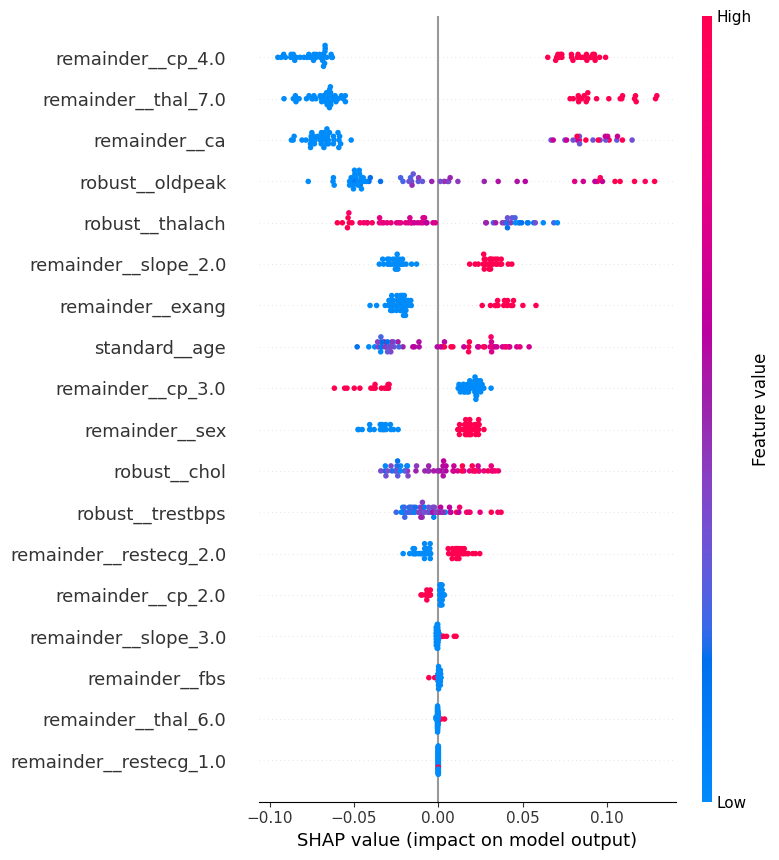

In [42]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

# Global feature importance
shap.summary_plot(shap_values[:,:,1], X_test_scaled, feature_names=preprocessor.get_feature_names_out())

TypeError: RandomForestClassifier.__init__() got an unexpected keyword argument 'threshold'